# Exploratory Data Analysis (EDA) for  McDonald’s financials

## SESSION 1: Introduction + Data Loading

Objective:

Understand dataset, import libraries, basic inspection

In [28]:
# Suppress warnings (for clean teaching output)
import warnings
warnings.filterwarnings('ignore')

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

In [29]:
# Load dataset
try:
    df = pd.read_csv("McDonalds_Financial_Statements.csv")
    print("Dataset loaded successfully")
except FileNotFoundError:
    print("Check file path!")

Dataset loaded successfully


In [34]:
print(df.shape)


(21, 17)


In [4]:
# View data
df.head()

,Year,Market cap ($B),Revenue ($B),Earnings ($B),P/E ratio,P/S ratio,P/B ratio,Operating Margin (%),EPS ($),Shares Outstanding ($B),Cash on Hand ($B),Dividend Yield (%),Dividend (stock split adjusted) ($),Net assets ($B),Total assets ($B),Total debt ($B),Total liabilities ($B)
0,2022,193.01,23.18,7.82,31.3,8.33,-32.2,33.76,8.42,0.73,2.58,2.15,5.66,-6.01,50.43,48.03,56.43
1,2021,200.31,23.22,9.12,26.5,8.63,-43.5,39.31,10.11,0.74,4.70,1.96,5.25,-4.61,53.60,48.64,58.20
2,2020,159.88,19.20,6.14,33.8,8.32,-20.4,31.97,6.35,0.74,3.44,2.35,5.04,-7.83,52.62,48.51,60.45
3,2019,147.47,21.28,8.01,24.8,6.93,-18.0,38.04,7.98,0.74,0.89,2.39,4.73,-8.22,47.51,46.87,55.72
4,2018,136.21,21.02,7.81,23.2,6.48,-21.8,37.17,7.65,0.76,0.86,2.36,4.19,-6.26,32.81,31.07,39.06


In [32]:
# Basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 21 non-null     int64  
 1   Market cap ($B)                      21 non-null     float64
 2   Revenue ($B)                         21 non-null     float64
 3   Earnings ($B)                        21 non-null     float64
 4   P/E ratio                            21 non-null     float64
 5   P/S ratio                            21 non-null     float64
 6   P/B ratio                            21 non-null     float64
 7   Operating Margin (%)                 21 non-null     float64
 8   EPS ($)                              21 non-null     float64
 9   Shares Outstanding ($B)              21 non-null     float64
 10  Cash on Hand ($B)                    21 non-null     float64
 11  Dividend Yield (%)                

In [31]:
# Summary statistics
print(df.describe(include='all'))

              Year  Market cap ($B)  Revenue ($B)  Earnings ($B)  P/E ratio  \
count    21.000000        21.000000     21.000000      21.000000  21.000000   
mean   2012.000000        96.824286     22.706190       6.214762  21.661905   
std       6.204837        50.396346      3.398316       2.226166   5.541974   
min    2002.000000        20.390000     15.400000       1.660000  15.000000   
25%    2007.000000        67.220000     20.810000       3.880000  16.500000   
50%    2012.000000        90.220000     22.820000       6.860000  21.400000   
75%    2017.000000       136.210000     24.620000       8.010000  24.800000   
max    2022.000000       200.310000     28.100000       9.120000  33.800000   

       P/S ratio  P/B ratio  Operating Margin (%)    EPS ($)  \
count  21.000000  21.000000             21.000000  21.000000   
mean    4.234762  -7.100000             26.889048   4.852857   
std     2.266896  19.356029              8.355580   2.507501   
min     1.320000 -45.900000     

Explanation:

head() → first 5 rows

info() → data types, missing values

describe() → statistical summary

Insight:

Helps identify numerical vs categorical columns

Detects missing values and anomalies early

## SESSION 2: Data Cleaning

Objective:

Handle missing values, duplicates, incorrect types

In [8]:
# Check missing values
df.isnull().sum()

Year                                   0
Market cap ($B)                        0
Revenue ($B)                           0
Earnings ($B)                          0
P/E ratio                              0
P/S ratio                              0
P/B ratio                              0
Operating Margin (%)                   0
EPS ($)                                0
Shares Outstanding ($B)                0
Cash on Hand ($B)                      0
Dividend Yield (%)                     0
Dividend (stock split adjusted) ($)    0
Net assets ($B)                        0
Total assets ($B)                      0
Total debt ($B)                        0
Total liabilities ($B)                 0
dtype: int64

In [26]:
# Fill or drop missing values
df.ffill(inplace=True)

In [10]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [27]:
# Convert date column if exists
#df['Date'] = pd.to_datetime(df['Date'])

In [33]:
df.columns = df.columns.str.strip()   # remove spaces
print(df.columns)

Index(['Year', 'Market cap ($B)', 'Revenue ($B)', 'Earnings ($B)', 'P/E ratio',
       'P/S ratio', 'P/B ratio', 'Operating Margin (%)', 'EPS ($)',
       'Shares Outstanding ($B)', 'Cash on Hand ($B)', 'Dividend Yield (%)',
       'Dividend (stock split adjusted) ($)', 'Net assets ($B)',
       'Total assets ($B)', 'Total debt ($B)', 'Total liabilities ($B)'],
      dtype='object')


In [49]:
df.columns = (
    df.columns
    .str.replace(r"\(.*?\)", "", regex=True)
    .str.strip()
    .str.replace(" ", "_")
    .str.lower()
)
print(df.columns)

Index(['year', 'market_cap', 'revenue', 'earnings', 'p/e_ratio', 'p/s_ratio',
       'p/b_ratio', 'operating_margin', 'eps', 'shares_outstanding',
       'cash_on_hand', 'dividend_yield', 'dividend', 'net_assets',
       'total_assets', 'total_debt', 'total_liabilities'],
      dtype='object')


Explanation:

fillna() → forward fill missing data

drop_duplicates() → removes repeated rows

Insight:

Clean data improves accuracy of analysis

Missing values can bias financial insights

## SESSION 3: Data Transformation

Objective:

Create new features, normalize data

In [50]:
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

In [52]:
# Example: Create Profit Margin
df['Profit_Margin'] = np.where(
    df['revenue'] != 0,
    df['earnings'] / df['revenue'],
    0
)

In [53]:

# Normalize a column
df['Revenue_Scaled'] = (df['revenue'] - df['revenue'].mean()) / df['revenue'].std()

In [69]:
#Rename columns
#df.rename(columns={'Net Income': 'Net_Income'}, inplace=True)

Explanation:

Feature engineering helps reveal hidden patterns

Scaling helps in ML models

Insight:

Profit margin reveals true performance vs revenue

Scaling makes comparisons fair across years

## SESSION 4: Statistical Analysis

Objective:

Understand relationships and distributions

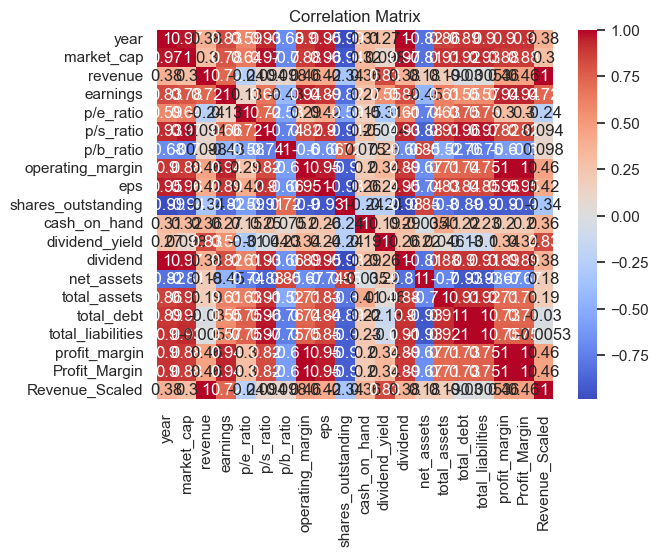

In [55]:
# Correlation matrix
corr = df.corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Explanation:

Shows relationship between variables (-1 to +1)

Insight:

Strong correlation between Revenue & Net Income

Helps identify key drivers of profit

### Distribution Plot:

Insight:

Shows whether revenue is stable or volatile

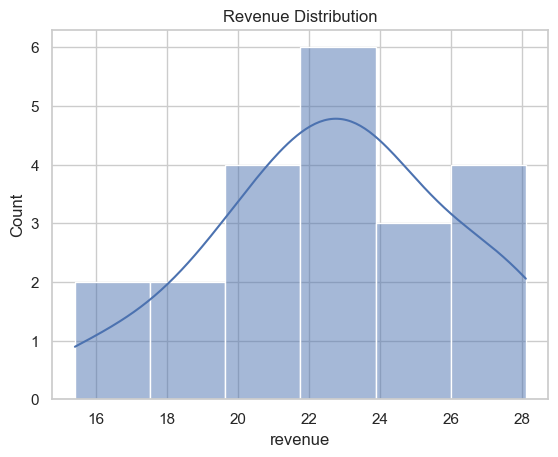

In [57]:
sns.histplot(df['revenue'], kde=True)
plt.title("Revenue Distribution")
plt.show()

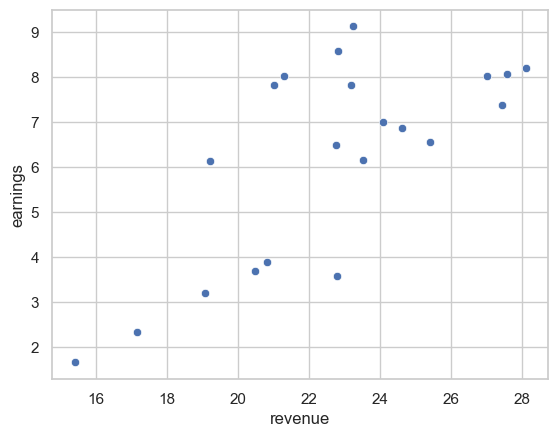

In [59]:
sns.scatterplot(data=df, x='revenue', y='earnings')
plt.show()

## SESSION 5: Data Visualization

Objective:

Visual storytelling

1. Revenue Trend

Insight:

Identifies growth or decline trends

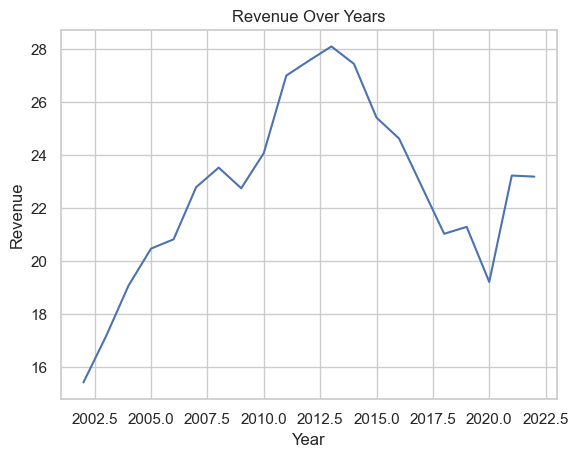

In [60]:
plt.plot(df['year'], df['revenue'])
plt.title("Revenue Over Years")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

2. Profit vs Revenue
Insight:

Shows whether higher revenue leads to higher profits

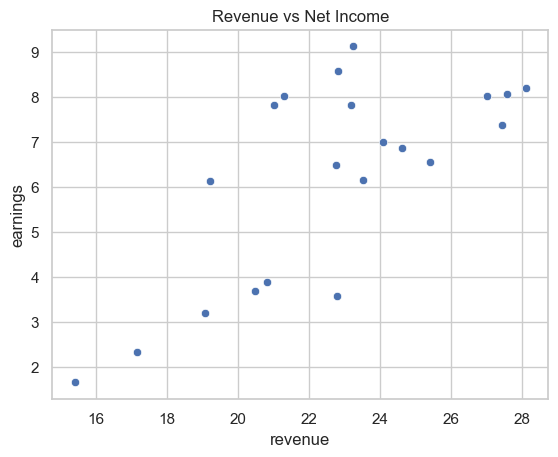

In [61]:
sns.scatterplot(x='revenue', y='earnings', data=df)
plt.title("Revenue vs Net Income")
plt.show()

3. Profit Margin Trend
Insight:

Detects efficiency changes over time

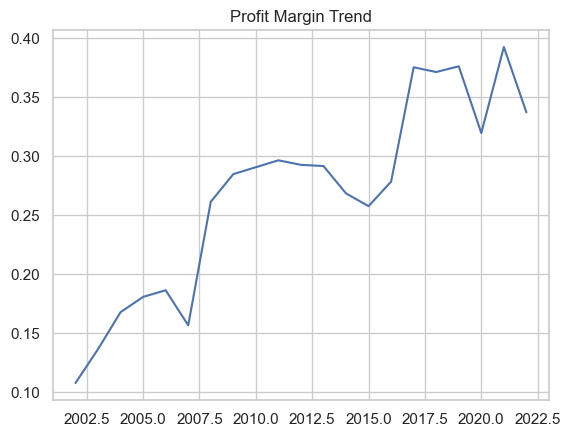

In [62]:
plt.plot(df['year'], df['Profit_Margin'])
plt.title("Profit Margin Trend")
plt.show()

4. Boxplot

Insight:

Detects outliers in financial data

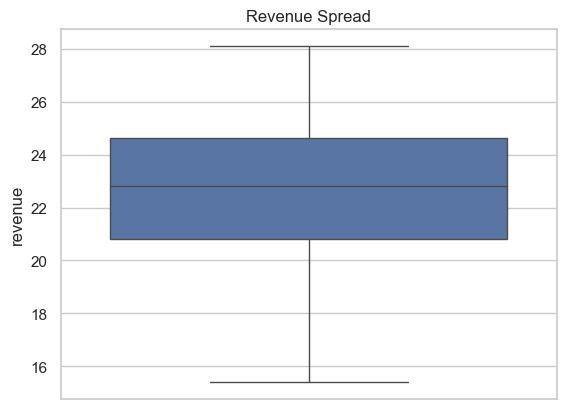

In [63]:
sns.boxplot(y=df['revenue'])
plt.title("Revenue Spread")
plt.show()

In [64]:
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['revenue'] >= Q1 - 1.5*IQR) & (df['revenue'] <= Q3 + 1.5*IQR)]

## SESSION 6: Basic Machine Learning

Objective:

Simple prediction using sklearn

### LINEAR REGRESSION

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Evaluate
print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.23258756524944324


Explanation:

Predict Net Income using Revenue

Insight:

Shows predictive relationship between variables

## Classification using Logistic Regression

Predict whether McDonald’s had High Earnings or Low Earnings

In [70]:
# Create binary target (1 = High Earnings, 0 = Low Earnings)
df['high_earnings'] = np.where(
    df['earnings'] > df['earnings'].median(),
    1,
    0
)

In [77]:
# Select Features
X = df[['revenue', 'market_cap']]
y = df['high_earnings']

In [78]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [79]:
# Train Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [80]:
# Predictions
y_pred = model.predict(X_test)

In [81]:
# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 3]]


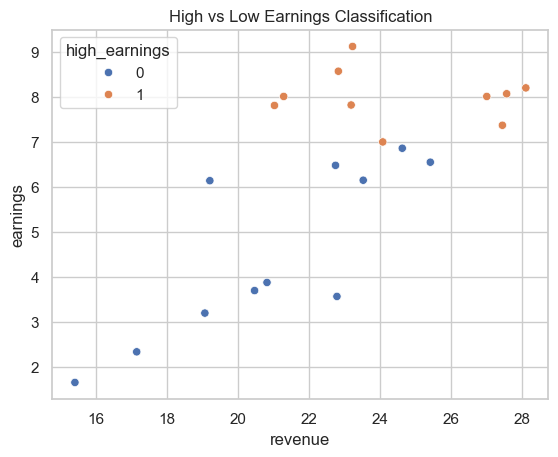

In [82]:
# Visualization
sns.scatterplot(data=df, x='revenue', y='earnings', hue='high_earnings')
plt.title("High vs Low Earnings Classification")
plt.show()

## QUESTIONS WITH ANSWERS

What does df.head() do?
→ Displays first 5 rows

Why handle missing values?
→ To avoid incorrect analysis

What is correlation?
→ Relationship between variables

What does heatmap show?
→ Correlation visually

Why use scaling?
→ Normalize data

What is profit margin?
→ Profit / Revenue

What does scatter plot show?
→ Relationship between 2 variables

What is outlier?
→ Extreme value

What does Linear Regression do?
→ Predicts continuous values

Why visualize data?
→ Easier understanding

## KEY INSIGHTS

Revenue shows long-term trend

Profit depends strongly on revenue

Profit margin reveals efficiency

Some years may have anomalies

Outliers affect analysis

Correlation helps decision-making

Visualization simplifies complex data

Clean data improves results

Feature engineering adds value

Simple ML can predict trends

## OVERALL CONCLUSION

This EDA project on McDonald’s financial dataset demonstrates how raw data can be transformed into meaningful insights through systematic steps: cleaning, transformation, analysis, and visualization. Students learn not only technical skills using libraries like Pandas, NumPy, Seaborn, and Scikit-learn, but also how to interpret business performance. The project bridges theory and real-world analytics, making it ideal for beginners in data analysis.